In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('../data/raw/store-data.csv', encoding="latin-1")

In [43]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10064.000000,9.863000e+03,9865.000000,10064.000000,10064.000000
mean,4994.397059,1.950322e+03,3.780233,0.157501,28.571309
std,2885.848580,4.410673e+04,2.240134,0.210586,233.509461
min,1.000000,4.440000e-01,-5.000000,0.000000,-6599.978000
25%,2496.750000,1.729000e+01,2.000000,0.000000,1.724800
50%,4989.500000,5.450000e+01,3.000000,0.200000,8.643600
75%,7494.250000,2.107600e+02,5.000000,0.200000,29.331600
max,9994.000000,1.131924e+06,14.000000,1.500000,8399.976000


In [44]:
df.describe(include="str")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10064,10064,9963,9763,10064,9713,10064,10064,10064,10064,9864,10064,10064,10064,10064,10064
unique,5009,1495,1334,4,793,810,6,1,633,86,705,4,1862,6,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035.0,West,OFF-PA-10001970,Office Supplies,Binders,Easy-staple paper
freq,14,39,35,5822,38,36,5163,10064,896,1967,259,3224,19,5942,1532,48


In [45]:
df.shape

(10064, 21)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10064 entries, 0 to 10063
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10064 non-null  int64  
 1   Order ID       10064 non-null  str    
 2   Order Date     10064 non-null  str    
 3   Ship Date      9963 non-null   str    
 4   Ship Mode      9763 non-null   str    
 5   Customer ID    10064 non-null  str    
 6   Customer Name  9713 non-null   str    
 7   Segment        10064 non-null  str    
 8   Country        10064 non-null  str    
 9   City           10064 non-null  str    
 10  State          10064 non-null  str    
 11  Postal Code    9864 non-null   str    
 12  Region         10064 non-null  str    
 13  Product ID     10064 non-null  str    
 14  Category       10064 non-null  str    
 15  Sub-Category   10064 non-null  str    
 16  Product Name   10064 non-null  str    
 17  Sales          9863 non-null   float64
 18  Quantity       98

In [47]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date        101
Ship Mode        301
Customer ID        0
Customer Name    351
Segment            0
Country            0
City               0
State              0
Postal Code      200
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales            201
Quantity         199
Discount           0
Profit             0
dtype: int64

In [48]:
df['Ship Mode'].isna().sum() # 301 order don't have shiping mode
df['Ship Mode'].mode() # Standard class is the most shiping mode assigned
df['Ship Mode'].value_counts()
df[df['Ship Mode'].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
28,29,US-2015-150630,9/17/2015,9/21/2015,NaN,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140.0,East,OFF-BI-10000474,Office Supplies,Binders,Avery Recycled Flexi-View Covers for Binding S...,9.618,2.0,0.7,-7.0532
94,95,CA-2015-149587,1/31/2015,2/5/2015,NaN,KB-16315,Karl Braun,Consumer,United States,Minneapolis,...,55407.0,Central,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,32.960,2.0,0.0,16.1504
191,192,CA-2015-102281,10/12/2015,10/14/2015,NaN,MP-17470,Mark Packer,Home Office,United States,New York City,...,10035.0,East,OFF-PA-10000061,Office Supplies,Paper,Xerox 205,51.840,8.0,0.0,24.8832
252,253,CA-2016-146941,12/10/2016,12/13/2016,NaN,DL-13315,Delfina Latchford,Consumer,United States,New York City,...,10024.0,East,OFF-ST-10001228,Office Supplies,Storage,"Fellowes Personal Hanging Folder Files, Navy",80.580,6.0,0.0,22.5624
314,315,CA-2014-167850,8/9/2014,8/16/2014,NaN,AG-10525,Andy Gerbode,Corporate,United States,Saint Petersburg,...,33710.0,South,TEC-PH-10002398,Technology,Phones,AT&T 1070 Corded Phone,178.384,2.0,0.2,22.2980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9911,9912,US-2014-157231,4/5/2014,4/9/2014,NaN,RP-19855,Roy Phan,Corporate,United States,Richmond,...,40475.0,South,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,115.360,7.0,0.0,56.5264
9964,9965,CA-2016-146374,12/5/2016,12/10/2016,NaN,HE-14800,Harold Engle,Corporate,United States,Newark,...,NaN,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.400,1.0,0.0,6.4320
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,NaN,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2.0,0.0,72.9480
10016,4904,CA-2017-110884,3/7/2017,3/12/2017,NaN,SH-20395,NaN,Consumer,United States,New York City,...,10035.0,East,OFF-LA-10003510,office supplies,Labels,Avery 4027 File Folder Labels for Dot Matrix P...,91.590,3.0,0.0,42.1314


In [49]:
df['City'] = df['City'].str.title()
df.drop_duplicates(['City'], keep=False)['Postal Code'].isna().sum()

np.int64(0)

In [50]:

dates_cols = ['Order Date', "Ship Date"]
df[dates_cols] = df[dates_cols].apply(pd.to_datetime, format="mixed")

df[dates_cols] = df[dates_cols].apply(lambda col: col.dt.strftime("%d/%m/%Y"))

(df['Ship Date'] < df["Order Date"]).sum()

np.int64(1159)

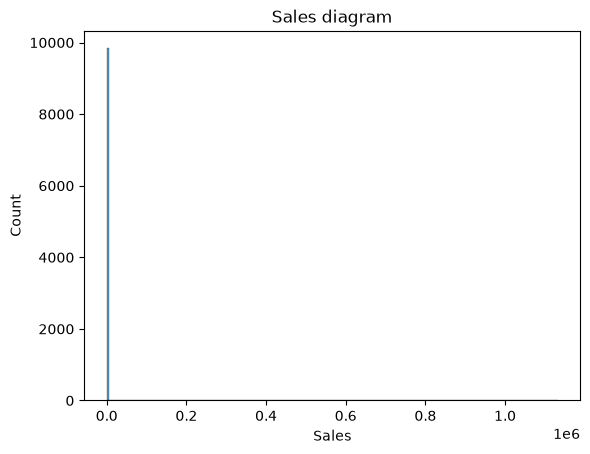

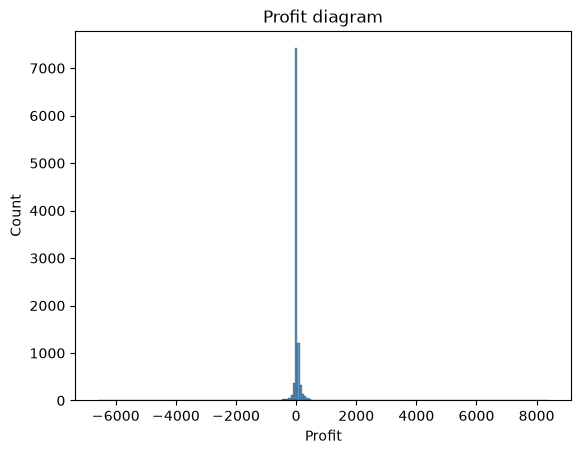

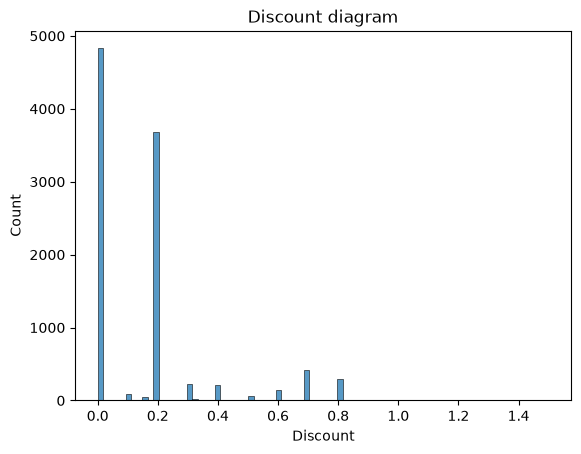

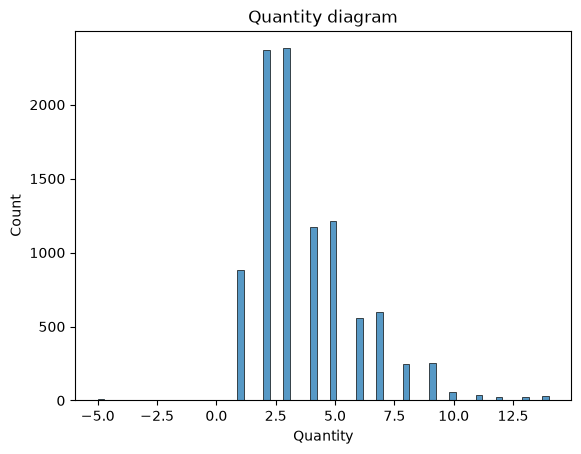

In [58]:
cols = ['Sales', 'Profit', 'Discount', 'Quantity']
for col in cols:
    sns.histplot(df[col])
    plt.title(f"{col} diagram")
    plt.show()

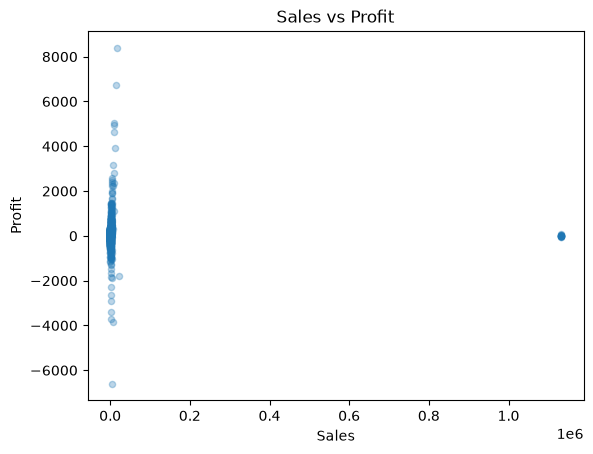

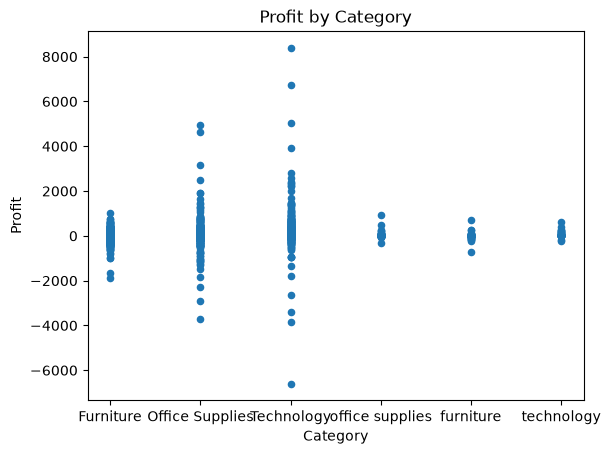

,Sales,Quantity,Discount,Profit
Sales,1.000000,-0.001902,0.004972,0.003309
Quantity,-0.001902,1.000000,0.014373,0.064227
Discount,0.004972,0.014373,1.000000,-0.215425
Profit,0.003309,0.064227,-0.215425,1.000000


In [61]:
df.plot.scatter(x='Sales', y='Profit', alpha=0.3)
plt.title('Sales vs Profit')
plt.show()

df.plot.scatter(y='Profit', x='Category')
plt.title('Profit by Category')
plt.show()

df[['Sales', 'Quantity', 'Discount', 'Profit']].corr() # correlation walo

(0.0, 200.0)

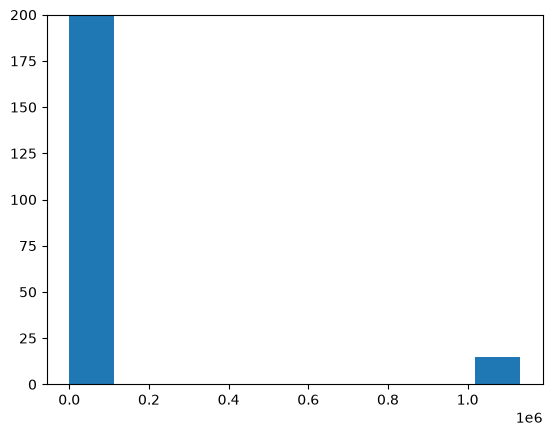

In [73]:
plt.hist(df['Sales'])
# plt.xlim(0, 10000)
plt.ylim(0, 200)